# 🛡️ Phishing SMS Detection in Bangladeshi Mobile Banking System
### Covers: bKash · Nagad · Rocket &nbsp;|&nbsp; Languages: English · Bengali · Banglish
> **High-Sensitivity Model** — any deviation from real MFS patterns is flagged as Spam.

## Step 1 — Import Libraries

In [4]:
import pandas as pd
import numpy as np
import re
import pickle
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix)

## Step 2 — Load & Merge All Datasets

In [5]:

 #Load the files (Make sure you uploaded them to Colab!)
try:
    df_bkash = pd.read_csv("bkash.csv")
    df_nagad = pd.read_csv("nagad.csv")
    df_rocket = pd.read_csv("rocket.csv")
    df_n = pd.read_csv("nagad_templete.csv")

    # Merge all dataset
    df = pd.concat([df_bkash, df_nagad, df_rocket, df_n], ignore_index=True)
    # Shuffle (Mix) them so they aren't in order
    df = df.sample(frac=1, random_state=42).reset_index(drop=True)

    print(f"✅ Step 1 Success! Total Messages Loaded: {len(df)}")
    print("Here is a sample of your data:")
    print(df.head())
    print()
    print(f"✅ Total messages loaded: {len(df):,}")
    print()
    print("Label distribution:")
    print(df['Label'].value_counts())
    print()
    print("Sub-category distribution:")
    print(df['Sub_Category'].value_counts())

except FileNotFoundError:
    print("❌ Stop! You haven't uploaded the CSV files yet.")

✅ Step 1 Success! Total Messages Loaded: 102580
Here is a sample of your data:
                                        Message_Body Label      Sub_Category
0  উপবৃত্তি ও বয়স্ক ভাতার টাকা পেতে এখনই যোগাযোগ...  Spam  Fake_Transaction
1  <#> Your registration reference number is 8864...   Ham        Real_bKash
2  Payment Tk 10,643.00 to Grameenphone is succes...   Ham             bKash
3  Cash In Tk 13,919.00 successful. Sender: 01899...  Spam  Fake_Transaction
4  Congrats! You won DBBL Rocket Lottery of Tk295...  Spam           Lottery

✅ Total messages loaded: 102,580

Label distribution:
Label
Spam    51308
Ham     51272
Name: count, dtype: int64

Sub-category distribution:
Sub_Category
Fake_Transaction    25173
Phishing            13353
bKash               10000
Real_bKash          10000
Nagad               10000
Real_Rocket          9982
Lottery              9951
Transaction          7014
Promo                2986
Threat               1549
Real_Nagad           1290
Fake_Refund      

## Step 3 — Text Cleaning
Preserves **Bengali Unicode** (\u0980–\u09FF) so Banglish and Bengali text are not destroyed.

In [6]:
import re

def clean_text(text):
    if not isinstance(text, str): return ""

    # 1. Make everything lowercase (Small letters)
    text = text.lower()

    # 2. Remove special symbols (!@#$) but KEEP Bangla and Numbers
    # The code \u0980-\u09FF represents all Bangla letters
    text = re.sub(r'[^\w\s\u0980-\u09FF]', ' ', text)

    # 3. Fix extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Apply this cleaner to all 40,000 messages
print("⏳ Cleaning data... please wait...")
df['Cleaned_Message'] = df['Message_Body'].apply(clean_text)

print("✅ Text cleaning complete.")
print(f"\nExample (English) :")
print(f"  Before : 'Cash In Tk 500!!!'")
print(f"  After  : '{clean_text('Cash In Tk 500!!!')}'")
print(f"\nExample (Bengali) :")
print(f"  Before  : 'আপনার বিকাশ অ্যাকাউন্ট সাময়িকভাবে বন্ধ!@'")
print(f"  After   : '{clean_text('আপনার বিকাশ অ্যাকাউন্ট সাময়িকভাবে বন্ধ!')}'")

⏳ Cleaning data... please wait...
✅ Text cleaning complete.

Example (English) :
  Before : 'Cash In Tk 500!!!'
  After  : 'cash in tk 500'

Example (Bengali) :
  Before  : 'আপনার বিকাশ অ্যাকাউন্ট সাময়িকভাবে বন্ধ!@'
  After   : 'আপনার বিকাশ অ্যাকাউন্ট সাময়িকভাবে বন্ধ'


## Step 4 — TF-IDF Feature Extraction

| Setting | Value | Why |
|---|---|---|
| `max_features` | 15,000 | Larger vocab catches more scam patterns |
| `ngram_range` | (1,3) | Single words + 2 & 3-word phrases like *"share your otp"* |
| `sublinear_tf` | True | Rare scam keywords get more weight |
| `min_df` | 2 | Ignore one-off typos |

In [7]:
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 3),   #Single words + 2 & 3-word phrases like "share your otp
    sublinear_tf=True,      #Rare scam keywords get more weight
    min_df=2,              #Ignore one-off typos
    analyzer='word',
    strip_accents=None,    # Keep Bengali characters intact
)

X = tfidf.fit_transform(df['Cleaned_Message'])
y = df['Label']

print(f"✅ TF-IDF complete.")
print(f"   Feature matrix: {X.shape[0]:,} messages × {X.shape[1]:,} features")

✅ TF-IDF complete.
   Feature matrix: 102,580 messages × 10,000 features


## Top Important Spam Feature



In [8]:
phishing_df = df[df['Label'] == 'Spam']

X_phish = tfidf.transform(phishing_df['Cleaned_Message'])

scores = np.asarray(X_phish.sum(axis=0)).flatten()

feature_importance = pd.DataFrame({
    'Feature': tfidf.get_feature_names_out(),
    'Score': scores
})

top_phishing = feature_importance.sort_values(
    by='Score',
    ascending=False
).head(15)
print(top_phishing)


      Feature        Score
5559     call  2101.593572
9224       to  1788.280117
7039       tk  1688.085329
9569     your  1558.990716
6297    nagad  1398.431233
5692  contact  1307.786758
4788  account  1305.518734
9543      you  1302.615729
5929     from  1227.427014
9518      won  1162.897468
6200  lottery  1159.837304
6752      ref  1085.309161
6820   rocket  1074.454731
0          00  1002.918430
9562  you won   981.740768


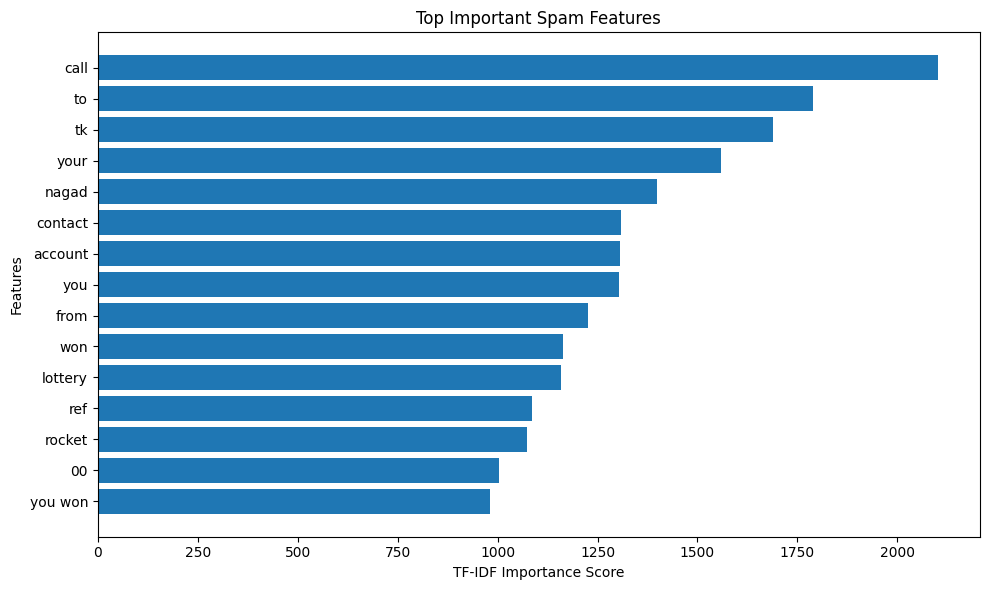

In [9]:
import matplotlib.pyplot as plt

top20 = feature_importance.sort_values(
    by='Score',
    ascending=False
).head(15)

plt.figure(figsize=(10,6))
plt.barh(top20['Feature'], top20['Score'])

plt.xlabel("TF-IDF Importance Score")
plt.ylabel("Features")
plt.title("Top Important Spam Features")

plt.gca().invert_yaxis()
plt.tight_layout()

plt.show()

## Step 5 — Train / Test Split

In [10]:


# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("✅ Step 4 Success! Data Split.")
print(f"Training Messages: {X_train.shape[0]}")
print(f"Testing Messages:  {X_test.shape[0]}")

✅ Step 4 Success! Data Split.
Training Messages: 82064
Testing Messages:  20516


## Step 6 — Train Hard Voting Classifier

**Why Hard Voting?**
LinearSVC does not output probabilities natively, making Hard Voting the natural choice.
A message needs at least **2 out of 3** classifiers to agree it is Ham — otherwise flagged Spam.

| Classifier | Role |
|---|---|
| LinearSVC | Best for high-dimensional text, very fast |
| LogisticRegression | Probabilistic, good at borderline cases |
| RandomForest | Catches non-linear scam patterns |

In [11]:


#print("🧠 Training the AI... (This might take 30-60 seconds)")

# 1. Define the 3 experts
clf1 = LinearSVC(random_state=42)
clf2 = LogisticRegression(random_state=42, max_iter=1000)
clf3 = RandomForestClassifier(n_estimators=50, random_state=42)

# 2. Create the Team (Voting Classifier)
# 'hard' voting means they vote, and majority wins
model = VotingClassifier(
    estimators=[('svm', clf1), ('lr', clf2), ('rf', clf3)],
    voting='hard'
)

# 3. Train the team
model.fit(X_train, y_train)

#print("✅ Step 5 Success! The AI has been trained.")

VotingClassifier(estimators=[('svm', LinearSVC(random_state=42)),
                             ('lr',
                              LogisticRegression(max_iter=1000,
                                                 random_state=42)),
                             ('rf',
                              RandomForestClassifier(n_estimators=50,
                                                     random_state=42))])

## Step 7 — Evaluate the Model

In [12]:


# Ask the AI to predict the test data
predictions = model.predict(X_test)

# Calculate the score
accuracy = accuracy_score(y_test, predictions)

print("\n" + "="*30)
print(f"🏆 FINAL ACCURACY: {accuracy*100:.2f}%")
print("="*30)

# Show detailed report
print(classification_report(y_test, predictions))


🏆 FINAL ACCURACY: 96.45%
              precision    recall  f1-score   support

         Ham       0.96      0.97      0.97     10410
        Spam       0.97      0.96      0.96     10106

    accuracy                           0.96     20516
   macro avg       0.96      0.96      0.96     20516
weighted avg       0.96      0.96      0.96     20516



## Step 8 — Confusion Matrix

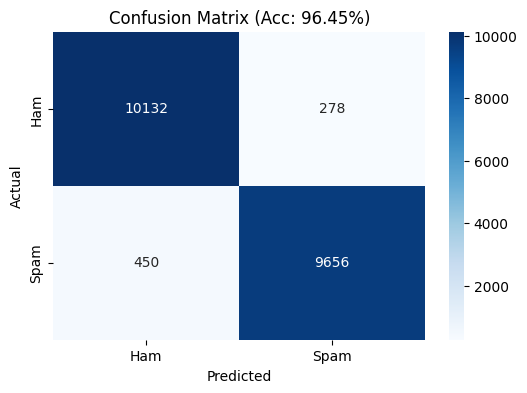


📊 Breakdown:
   ✅ True  Negatives (real msgs safe)  : 10,132
   ✅ True  Positives (scams caught)     : 9,656
   ⚠️  False Positives (real flagged)    : 278
   🚨 False Negatives (scams missed)     : 450

   Precision : 97.20%
   Recall    : 95.55%
   F1-Score  : 96.37%


In [13]:
# 8. VISUALIZE CONFUSION MATRIX
cm = confusion_matrix(y_test, predictions)
tn, fp, fn, tp = cm.ravel()

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.title(f'Confusion Matrix (Acc: {accuracy*100:.2f}%)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print(f"\n📊 Breakdown:")
print(f"   ✅ True  Negatives (real msgs safe)  : {tn:,}")
print(f"   ✅ True  Positives (scams caught)     : {tp:,}")
print(f"   ⚠️  False Positives (real flagged)    : {fp:,}")
print(f"   🚨 False Negatives (scams missed)     : {fn:,}")

precision = (tp / (tp + fp)) if (tp + fp) > 0 else 0
recall = (tp / (tp + fn)) if (tp + fn) > 0 else 0

# Calculate F1-Score
f1_score = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print(f"\n   Precision : {precision * 100:.2f}%")
print(f"   Recall    : {recall * 100:.2f}%")
print(f"   F1-Score  : {f1_score * 100:.2f}%")

## Step 9 — Individual Model vs Ensemble Comparison

In [14]:

print("⏳ Evaluating individual models...")

svm_cal = CalibratedClassifierCV(LinearSVC(C=0.8, max_iter=3000, random_state=42))
svm_cal.fit(X_train, y_train)
svm_acc = accuracy_score(y_test, svm_cal.predict(X_test))

lr_solo = LogisticRegression(C=0.8, max_iter=1000, random_state=42, class_weight='balanced')
lr_solo.fit(X_train, y_train)
lr_acc = accuracy_score(y_test, lr_solo.predict(X_test))

rf_solo = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced', n_jobs=-1)
rf_solo.fit(X_train, y_train)
rf_acc = accuracy_score(y_test, rf_solo.predict(X_test))



⏳ Evaluating individual models...


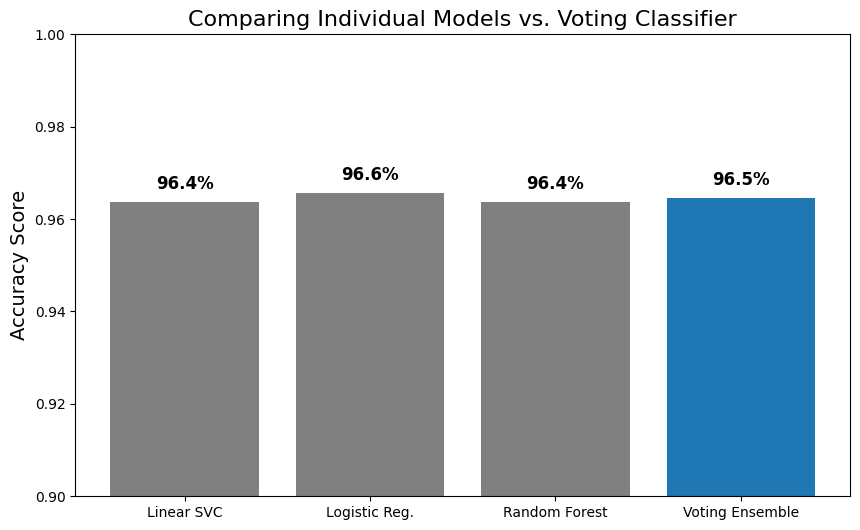

  Linear SVC          : 96.37%
  Logistic Reg.       : 96.56%
  Random Forest       : 96.37%
  Voting Ensemble     : 96.45%


In [15]:


# 1. Define accuracies (You can type these manually from your previous results)
# Example: If SVM got 95%, LR got 94%, RF got 96%, Voting got 96.5%
models = ['Linear SVC', 'Logistic Reg.', 'Random Forest', 'Voting Ensemble']
scores      = [svm_acc, lr_acc, rf_acc, accuracy]

# 2. Plot
plt.figure(figsize=(10, 6))
# Highlight the winner (Voting) in a different color
colors = ['grey', 'grey', 'grey', '#1f77b4']
bars = plt.bar(models, scores, color=colors)

# 3. Add text labels on top
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.002, f'{yval*100:.1f}%',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.ylim(0.90, 1.0) # Zoom in to make differences visible
plt.title('Comparing Individual Models vs. Voting Classifier', fontsize=16)
plt.ylabel('Accuracy Score', fontsize=14)
plt.show()

for n, s in zip(models, scores):
    print(f"  {n:<20}: {s*100:.2f}%")


## Step 10 — High-Sensitivity Scam Detector

**Dual-gate logic:**
1. Voting Classifier must predict **Ham**
2. Logistic Regression must be **≥ 70% confident** it is Ham

If either condition fails → **SCAM**. This catches borderline and manipulated messages.

In [16]:
# Train probability-based LR for the confidence gate
lr_prob = LogisticRegression(C=0.8, max_iter=1000, random_state=42, class_weight='balanced')
lr_prob.fit(X_train, y_train)

HAM_THRESHOLD = 0.70   # 70% confidence required to pass as Ham

def check_scam(message, threshold=HAM_THRESHOLD, verbose=True):
    """
    Returns 'Ham' or 'Spam'.
    BOTH gates must pass for a message to be marked Safe:
      Gate 1 — Voting Classifier predicts Ham
      Gate 2 — LR confidence for Ham >= threshold
    """
    clean    = clean_text(message)
    vec      = tfidf.transform([clean])
    vote     = model.predict(vec)[0]
    proba    = lr_prob.predict_proba(vec)[0]
    ham_conf = proba[list(lr_prob.classes_).index('Ham')]
    result   = 'Ham' if (vote == 'Ham' and ham_conf >= threshold) else 'Spam'

    if verbose:
        icon = "✅ SAFE " if result == 'Ham' else "🚨 SCAM "
        preview = message[:90] + ('...' if len(message) > 90 else '')
        print(f"{icon} [{ham_conf*100:.1f}% Ham conf] → {preview}")

    return result

print(f"✅ High-sensitivity detector ready. Threshold = {HAM_THRESHOLD}")

✅ High-sensitivity detector ready. Threshold = 0.7


In [17]:
print("=" * 65)
print("  ✅ SAFE MESSAGES (should all pass)")
print("=" * 65)
check_scam("You have received Tk 5000.00 from 01711234567. Fee Tk 0.00. Balance Tk 12345.00. TrxID AB1234XY at 25/05/2026 10:30")
check_scam("Payment of Tk 639.90 to Foodpanda Bangladesh is successful. Balance Tk 5245.93. TrxID 75BS0ZF7 at 09/05/2026 18:33")
check_scam("Add Money from Bank is Successful. From: Eastern Bank PLC. Amount: Tk 5000.0. TxnID: 75CZIQQK. Balance: Tk 8377.82. 16/05/2026 15:21")
check_scam("Cash Out Tk 2000.00 from Agent 01812345678. Fee Tk 15.00. Balance Tk 3400.50. TrxID XY9876ZA at 20/05/2026 14:00")
check_scam("Your Account Binding bKash Verification Code is 638214. It will expire in 5 minutes. Please do NOT share your OTP or PIN with others.")

print()
print("=" * 65)
print("  🚨 SCAM MESSAGES (should all be flagged)")
print("=" * 65)
check_scam("Congratulations! You won a lottery of Tk 383,627. Call 01468838414 now.")
check_scam("ALERT: Your bKash account is suspended. Call 01912345678 immediately to restore.")
check_scam("Your OTP is 583921. Share it with our agent 01798765432 to verify your account.")
check_scam("Payment done successfully! give me pin")
check_scam("থ্যালাসেমিয়া রোগীদের মুখে হাসি ফুটাতে nagad bdlotteryticket com থেকে টিকেট কিনুন")
check_scam("Apnar bKash account verify na korle block hobe. Ekhoni call korun: 01812345678.")

print()
print("=" * 65)
print("  ⚠️  EDGE CASES (slightly modified real messages — should be flagged)")
print("=" * 65)
check_scam("You have received Tk 5000.00 from 01711234567. Balance Tk 12345.00. Call 01711234567 if mistake.")
check_scam("bKash: Payment of Tk 500 to Foodpanda successful. Not you? Call 01900000000 immediately.")
check_scam("Nagad: Your OTP is 123456. Please share with agent to verify. Validity: 2 minutes.")

  ✅ SAFE MESSAGES (should all pass)
✅ SAFE  [98.7% Ham conf] → You have received Tk 5000.00 from 01711234567. Fee Tk 0.00. Balance Tk 12345.00. TrxID AB1...
✅ SAFE  [97.8% Ham conf] → Payment of Tk 639.90 to Foodpanda Bangladesh is successful. Balance Tk 5245.93. TrxID 75BS...
✅ SAFE  [94.8% Ham conf] → Add Money from Bank is Successful. From: Eastern Bank PLC. Amount: Tk 5000.0. TxnID: 75CZI...
✅ SAFE  [95.7% Ham conf] → Cash Out Tk 2000.00 from Agent 01812345678. Fee Tk 15.00. Balance Tk 3400.50. TrxID XY9876...
✅ SAFE  [99.1% Ham conf] → Your Account Binding bKash Verification Code is 638214. It will expire in 5 minutes. Pleas...

  🚨 SCAM MESSAGES (should all be flagged)
🚨 SCAM  [0.6% Ham conf] → Congratulations! You won a lottery of Tk 383,627. Call 01468838414 now.
🚨 SCAM  [8.4% Ham conf] → ALERT: Your bKash account is suspended. Call 01912345678 immediately to restore.
🚨 SCAM  [45.7% Ham conf] → Your OTP is 583921. Share it with our agent 01798765432 to verify your account.
🚨 SC

'Spam'